# 1. Configuração do ambiente

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importação do dataset

In [2]:
data = pd.read_csv('./data/heart_disease_uci.csv')

### Sobre o Dataset Heart Disease

Fonte: conjunto consolidado dos quatro datasets da UCI (Cleveland, Hungarian, Switzerland e VA Long Beach), disponibilizado no [Kaggle](
https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data/data) já com alguns tratamentos de texto. O dataset original por ser encontrado em: https://archive.ics.uci.edu/dataset/45/heart+disease):

- Observações: 920
- Colunas: 16 (inclui metadados como id e dataset)
- Alvo original: num (0–4), onde 0 = ausência de doença e 1–4 = presença em diferentes graus
- Valores ausentes: presentes em múltiplos campos (ex.: trestbps, chol, thalch, exang, oldpeak, slope, ca, thal)

### Esquema das Variáveis (conforme Kaggle)

- id: identificador do paciente
- dataset: origem do caso (Cleveland, Hungarian, Switzerland, VA Long Beach)
- age: idade (anos)
- sex: sexo (Male/Female)
- cp: tipo de dor no peito (typical angina, atypical angina, non-anginal, asymptomatic)
- trestbps: pressão arterial em repouso (mmHg)
- chol: colesterol sérico (mg/dl)
- fbs: glicemia em jejum > 120 mg/dl (True/False)
- restecg: ECG em repouso (normal, st-t abnormality, lv hypertrophy)
- thalch: frequência cardíaca máxima alcançada
- exang: angina induzida por exercício (True/False)
- oldpeak: depressão do ST induzida por exercício (unidades “ST depression”)
- slope: inclinação do segmento ST de pico (upsloping, flat, downsloping)
- ca: número de vasos principais coloridos por fluoroscopia (0–3)
- thal: estado talassêmico (normal, fixed defect, reversable defect)
- num: diagnóstico (0 = sem doença; 1–4 = presença)

In [3]:
data.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [5]:
data.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


# 3.EDA - Analise de missing values

            Coluna  Missing_Count  Missing_Percentage
ca              ca            611               66.41
thal          thal            486               52.83
slope        slope            309               33.59
fbs            fbs             90                9.78
oldpeak    oldpeak             62                6.74
trestbps  trestbps             59                6.41
thalch      thalch             55                5.98
exang        exang             55                5.98
chol          chol             30                3.26
restecg    restecg              2                0.22


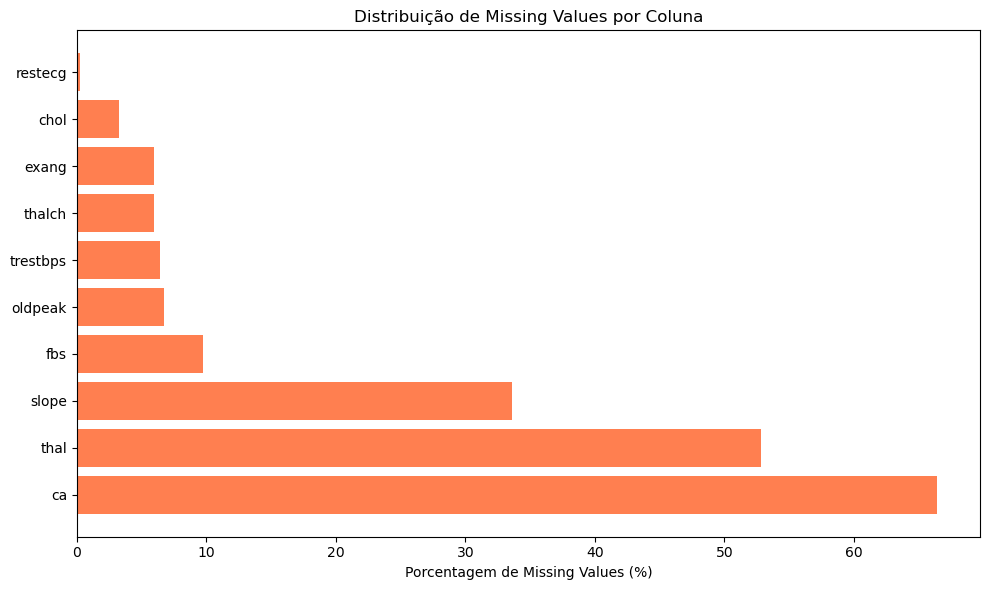

In [7]:
data.isnull().sum()

missing_values = pd.DataFrame({
    'Coluna': data.columns,
    'Missing_Count': data.isnull().sum(),
    'Missing_Percentage': (data.isnull().sum() / len(data) * 100).round(2)
})

missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values(
    by='Missing_Percentage', ascending=False
)

if len(missing_values) > 0:
    print(missing_values)
    
    # Visualizar missing values
    plt.figure(figsize=(10, 6))
    plt.barh(missing_values['Coluna'], missing_values['Missing_Percentage'], color='coral')
    plt.xlabel('Porcentagem de Missing Values (%)')
    plt.title('Distribuição de Missing Values por Coluna')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum missing value detectado!")

# 3.EDA - Analise da variavel alvo "NUM" (diagnóstico 0 = sem doença  e 1-4 = presença)

=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

Contagem:
target
1    509
0    411
Name: count, dtype: int64

Percentual:
Com doença (1): 55.33%
Sem doença (0): 44.67%


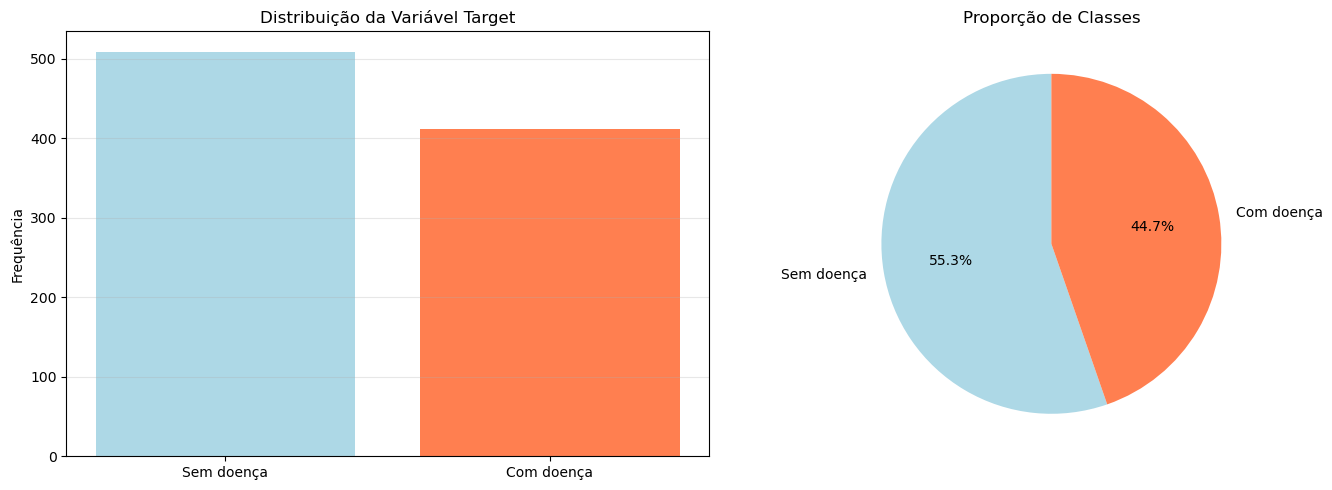


Ratio de balanceamento: 0.81
✓ Dataset razoavelmente balanceado.


In [9]:
# Renomear variável `num` para `target`
data.rename(columns={'num': 'target'}, inplace=True)

# Converter target para binário (0 = sem doença, 1 = com doença)
# No dataset original, valores > 0 indicam presença de doença
data['target'] = (data['target'] > 0).astype(int)

print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
target_counts = data['target'].value_counts()
target_percentages = data['target'].value_counts(normalize=True) * 100

print("Contagem:")
print(target_counts)
print("\nPercentual:")
for idx, pct in target_percentages.items():
    label = "Sem doença" if idx == 0 else "Com doença"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(['Sem doença', 'Com doença'], target_counts.values, color=['lightblue', 'coral'])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Target')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(target_counts.values, labels=['Sem doença', 'Com doença'], 
            autopct='%1.1f%%', colors=['lightblue', 'coral'], startangle=90)
axes[1].set_title('Proporção de Classes')

plt.tight_layout()
plt.show()

# Verificar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.")
else:
    print("✓ Dataset razoavelmente balanceado.")

# 3. EDA  - Analise de outliers

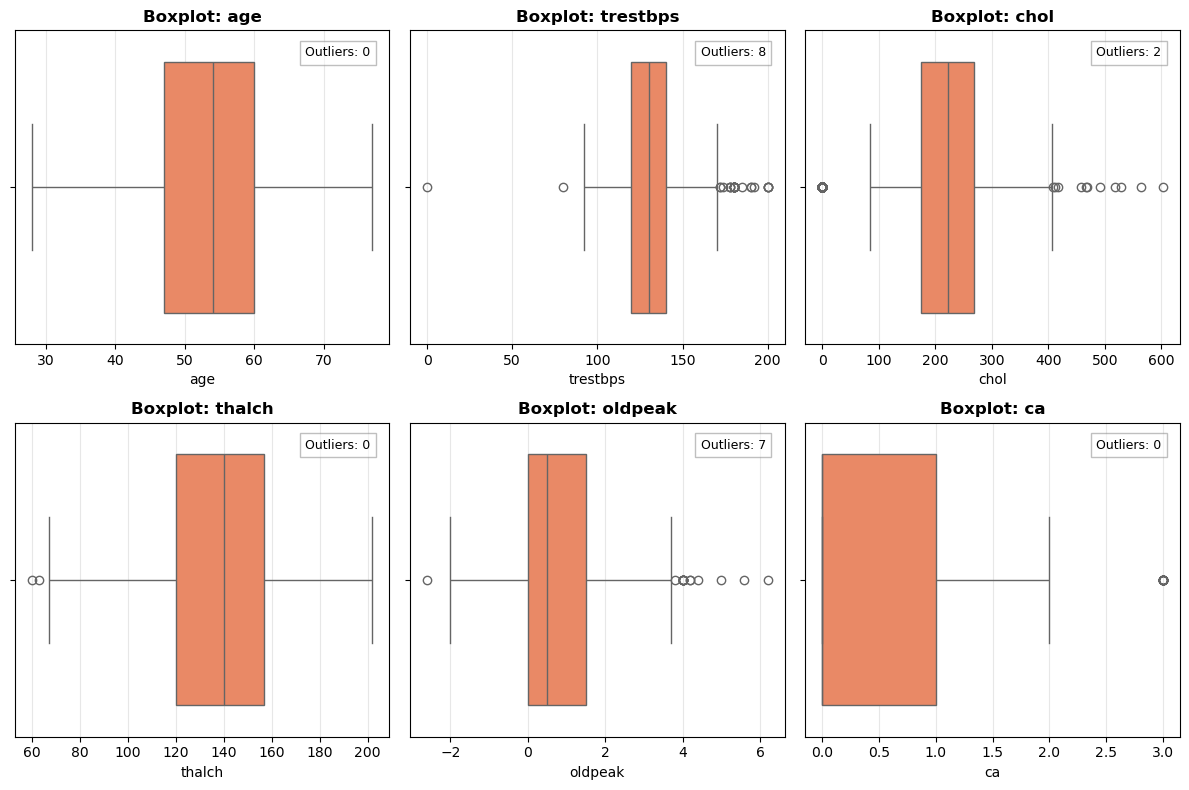

In [11]:
# Colunas numéricas (excluindo id e target)
from scipy import stats


numeric_cols = data.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['id', 'target'])

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=data[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(data[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}', 
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


# 3. EDA - LIMPEZA E TRATAMENTO DE DADOS

1. Missing values
2. Lidar com variáveis textuais - encoding
3. Slipt de dados - Separação dos dados para treino e para teste

In [14]:
# Lidando com missing values
# Opções: ignorar os nulos ou preencher esse valor com técnicas

# Estratégias
# 1 - remoção dos dados nulos: perda de informação e redução da amostra de dados
# 2 - imputação de valores estimados = media, medianos, moda



data_normalized = data.copy()
missing_numerics=['trestbps','chol','thalch','oldpeak','ca']


# Imputacao para valores numericos: media
for col in missing_numerics: #passando por cada coluna que listamos que possui nulos
    if col in data_normalized.columns: #verificando se a coluna existe no dataframe
        median = data_normalized[col].median() #pegando a mediana da coluna
        data_normalized[col].fillna(value=median, inplace=True) #para cada coluna que possui nulo, preencher com o valor da variavel mediana
        print(f'A {col} foi imputada com valor mediana: {median}')


missing_categorics =['thal','slope','fbs','exang','restecg']
# Imputacao para valores categoricos: moda  
for col in missing_categorics: #passando por cada coluna que listamos que possui nulos
    if col in data_normalized.columns: #verificando se a coluna existe no dataframe
        mode = data_normalized[col].mode()[0] #pegando a mediana da coluna
        data_normalized[col].fillna(value=mode, inplace=True) #para cada coluna que possui nulo, preencher com o valor da variavel mediana
        print(f'A {col} foi imputada com valor mediana: {mode}')

print(data_normalized.shape)
print(data_normalized.isnull().sum())

A trestbps foi imputada com valor mediana: 130.0
A chol foi imputada com valor mediana: 223.0
A thalch foi imputada com valor mediana: 140.0
A oldpeak foi imputada com valor mediana: 0.5
A ca foi imputada com valor mediana: 0.0
A thal foi imputada com valor mediana: normal
A slope foi imputada com valor mediana: flat
A fbs foi imputada com valor mediana: False
A exang foi imputada com valor mediana: False
A restecg foi imputada com valor mediana: normal
(920, 16)
id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


C:\Users\lara-\AppData\Local\Temp\ipykernel_2288\3883368915.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_normalized[col].fillna(value=median, inplace=True) #para cada coluna que possui nulo, preencher com o valor da variavel mediana
C:\Users\lara-\AppData\Local\Temp\ipykernel_2288\3883368915.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the i

# Realizando o One Hot Encoding para criar colunas binarias para variaveis categoricas

In [23]:
#data_normalized.drop(columns=['dataset'], inplace=True)

categorics_cols = ['sex','cp','restecg','slope','thal'] #passando as principais colunas categoricas
data_normalized_encoded = pd.get_dummies(data_normalized, columns=categorics_cols, drop_first=True) #realizando o encoding para essas variaveis

data_normalized_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        920 non-null    int64  
 1   age                       920 non-null    int64  
 2   trestbps                  920 non-null    float64
 3   chol                      920 non-null    float64
 4   fbs                       920 non-null    bool   
 5   thalch                    920 non-null    float64
 6   exang                     920 non-null    bool   
 7   oldpeak                   920 non-null    float64
 8   ca                        920 non-null    float64
 9   target                    920 non-null    int64  
 10  sex_Male                  920 non-null    bool   
 11  cp_atypical angina        920 non-null    bool   
 12  cp_non-anginal            920 non-null    bool   
 13  cp_typical angina         920 non-null    bool   
 14  restecg_no

In [22]:
data_normalized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  920 non-null    float64
 5   chol      920 non-null    float64
 6   fbs       920 non-null    bool   
 7   restecg   920 non-null    object 
 8   thalch    920 non-null    float64
 9   exang     920 non-null    bool   
 10  oldpeak   920 non-null    float64
 11  slope     920 non-null    object 
 12  ca        920 non-null    float64
 13  thal      920 non-null    object 
 14  target    920 non-null    int64  
dtypes: bool(2), float64(5), int64(3), object(5)
memory usage: 95.4+ KB


In [21]:
print(data_normalized['sex'].value_counts())

sex
Male      726
Female    194
Name: count, dtype: int64


# 4. Treinamento do modelo MVP

In [24]:
from sklearn.model_selection import train_test_split

# Dividir o dataset em features 
x = data_normalized_encoded.drop(columns=['id','target'])
y = data_normalized_encoded['target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [26]:
pip install mlflow  

   ---------------------------------------- 0.0/10.2 MB ? eta -:--:--
   ---------------------------- ----------- 7.3/10.2 MB 36.2 MB/s eta 0:00:01
   ---------------------------------------  10.0/10.2 MB 37.3 MB/s eta 0:00:01
   ---------------------------------------- 10.2/10.2 MB 18.1 MB/s  0:00:00
   ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
   ---------------------------------------- 3.0/3.0 MB 26.3 MB/s  0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 12.7 MB/s  0:00:00
   ---------------------------------------- 0.0/829.5 kB ? eta -:--:--
   ---------------------------------------- 829.5/829.5 kB 12.3 MB/s  0:00:00

   ----------------------------------------  0/24 [huey]
   ----------------------------------------  0/24 [huey]
   ----------------------------------------  0/24 [huey]
   ----------------------------------------  0/24 [huey]
   - ----------------------------

In [ ]:
import mlflow
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

mlflow.set_experiment("heart_disease_classification")

with mlflow.start_run(run_name="logistic_regression_baseline"):
    model = LogisticRegression(random_state=42)
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_recall = recall_score(y_test, y_pred_test)

    mlflow.log_metric("train_accuracy", train_accuracy)
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("test_f1_score", test_f1)
    mlflow.log_metric("test_precision", test_precision)
    mlflow.log_metric("test_recall", test_recall)

    overfitting = train_accuracy - test_accuracy
    mlflow.log_metric("overfitting", overfitting)

    mlflow.sklearn.log_model(model, "model")

    print(f"=== LOGISTIC REGRESSION ===")
    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy:  {test_accuracy:.4f}")
    print(f"Test F1 Score:  {test_f1:.4f}")

    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall:    {test_recall:.4f}")
    print(f"Overfitting:    {overfitting:.4f}")